<a href="https://colab.research.google.com/github/hendy90ID/KopiNangkau-Project/blob/main/KopiNangkau%20Project%20(harisenin.com)%20using%20Google%20Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kopi NangKau dengan [fill with your creativity]

## [DATASET.CSV](https://drive.google.com/file/d/1D1hdilPgi6nB8W3HAHnB1Jx87OJBScm8/view?usp=sharing)

In [1]:
!gdown 1D1hdilPgi6nB8W3HAHnB1Jx87OJBScm8

Downloading...
From: https://drive.google.com/uc?id=1D1hdilPgi6nB8W3HAHnB1Jx87OJBScm8
To: /content/penjualan_kopi_2021_2023.csv
100% 232k/232k [00:00<00:00, 27.6MB/s]


In [2]:
# Petunjuk/Hint

# Import library untuk komputasi numerik dan array (dasar dari Pandas).
# Docs: https://numpy.org/doc/
import numpy as np

# Import library untuk manipulasi dan analisis data tabular (DataFrame).
# Docs: https://pandas.pydata.org/docs/
import pandas as pd

# Import library fundamental untuk membuat visualisasi data (grafik, plot).
# Docs: https://matplotlib.org/stable/contents.html
import matplotlib.pyplot as plt

# Import library visualisasi data statistik yang dibangun di atas Matplotlib.
# Docs: https://seaborn.pydata.org/
import seaborn as sns

!pip install itables
from itables import show

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 25.7 MB/s eta 0:00:00


## **Skenario:**

Selamat! Kamu baru saja direkrut sebagai `Data Analyst` di `Kopi NangKau`. Kamu diberikan data penjualan harian dari tahun 2021 hingga 2023. Data ini berisi penjualan berbagai produk minuman dan makanan di toko, tapi terdapat data dobel (duplikat) dan beberapa nilai kosong (missing value).

Tugas kamu adalah membersihkan, mengolah, dan menganalisis data penjualan supaya bisnis bisa terus berkembang.

---

### 💡 Informasi Dasar Harga Produk

| Produk      | Harga Dasar Tahun 2021 (Rp) |
|-------------|----------------------------|
| Espresso    | 22.000                     |
| Latte       | 28.000                     |
| Cappuccino  | 25.000                     |
| Americano   | 21.000                     |
| Croissant   | 18.000                     |
| Donat       | 15.000                     |

- **Harga setiap produk naik 2% setiap tahun**  
  Contoh: Jika harga awal Espresso 22.000 di 2021, maka di 2023:  
  Tahun 2022 → 22.000 × 1.02 = 22.440  
  Tahun 2023 → 22.000 × 1.04 = 22.880 (pembulatan ke bawah karena integer di kode)

---
## TUGAS 1: Eksplorasi Data

1. Baca dataset ke pandas DataFrame.
2. Tampilkan 10 baris pertama.
3. Hitung jumlah baris, kolom, baris duplikat, serta missing value per kolom.
4. Pastikan Kolom Unit_Terjual dan Harga_Per_Unit

In [3]:
# no.1 dan no.2
df = pd.read_csv("/content/penjualan_kopi_2021_2023.csv", sep=";")
show(df.head(10))

Loading ITables v2.7.0 from the internet... (need help?)


In [4]:
# no.3 dan no.4
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6600 entries, 0 to 6599
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Tahun           6600 non-null   int64  
 1   Bulan           6600 non-null   object 
 2   Tanggal         6600 non-null   int64  
 3   Produk          6100 non-null   object 
 4   Unit_Terjual    6100 non-null   float64
 5   Harga_Per_Unit  6100 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 309.5+ KB



---

## TUGAS 2: Data Cleaning & Imputasi

1. Untuk baris di mana **Produk kosong tapi Harga_Per_Unit ada**:  
   - Lengkapi nilai Produk dengan cara mencocokkan harga dan tahun pada daftar harga.
2. Untuk baris di mana **Harga_Per_Unit kosong tapi Produk ada**:  
   - Lengkapi Harga_Per_Unit berdasar produk dan tahun (lihat tabel harga & rumus kenaikan).
3. Untuk baris dengan **Produk & Harga_Per_Unit sama-sama kosong**, hapus baris tersebut.
4. Untuk **Unit_Terjual** yang kosong, langsung hapus baris.
5. Pastikan tidak ada nilai negatif di Unit_Terjual.
6. Hapus baris duplikat.

In [5]:
# no. 4
# menghapus baris 'Unit_Terjual' yang null
df[df['Unit_Terjual'].isna()]
df1 = df.copy()
df1.dropna(subset = 'Unit_Terjual', inplace=True)
df1.info()


<class 'pandas.core.frame.DataFrame'>
Index: 6100 entries, 0 to 6599
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Tahun           6100 non-null   int64  
 1   Bulan           6100 non-null   object 
 2   Tanggal         6100 non-null   int64  
 3   Produk          5646 non-null   object 
 4   Unit_Terjual    6100 non-null   float64
 5   Harga_Per_Unit  5635 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 333.6+ KB


In [6]:
# menghapus baris 'Produk" dan 'Harga_Per_Unit' yang null
df2 = df1.copy()
df2.dropna(subset=['Produk','Harga_Per_Unit'], how='all', inplace=True)
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6066 entries, 0 to 6598
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Tahun           6066 non-null   int64  
 1   Bulan           6066 non-null   object 
 2   Tanggal         6066 non-null   int64  
 3   Produk          5646 non-null   object 
 4   Unit_Terjual    6066 non-null   float64
 5   Harga_Per_Unit  5635 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 331.7+ KB


In [7]:
# membuat daftar harga
dftr_hrg2021 = np.array([22000,28000,25000,21000,18000,15000])
dftr_hrg2022 = np.array(dftr_hrg2021) * 1.02
dftr_hrg = np.append(dftr_hrg2021, dftr_hrg2022, axis=0)
dftr_hrg2023 = np.array(dftr_hrg2021) * 1.04
dftr_hrg = np.append(dftr_hrg, dftr_hrg2023, axis=0)
dftr_hrg = dftr_hrg.reshape(3,6)
nama_produk = np.array(['Espresso','Latte','Cappuccino','Americano','Croissant','Donat'])
tahun = np.array([2021,2022,2023])
print(tahun)
print(nama_produk)
print(dftr_hrg)

[2021 2022 2023]
['Espresso' 'Latte' 'Cappuccino' 'Americano' 'Croissant' 'Donat']
[[22000. 28000. 25000. 21000. 18000. 15000.]
 [22440. 28560. 25500. 21420. 18360. 15300.]
 [22880. 29120. 26000. 21840. 18720. 15600.]]


In [8]:
# populasi data 'Harga' yang null
data_ref = []
for t_idx, t in enumerate(tahun):
  for p_idx, p in enumerate(nama_produk):
    data_ref.append({'Tahun':t,'Produk':p,'Harga_Ref':dftr_hrg[t_idx][p_idx]})

df_ref = pd.DataFrame(data_ref)
df_ref

df3 = df2.merge(df_ref, on=['Tahun', 'Produk'], how='left')
df3['Harga_Per_Unit'] = df3['Harga_Per_Unit'].fillna(df3['Harga_Ref'])
df3.drop(columns='Harga_Ref', inplace=True)
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6066 entries, 0 to 6065
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Tahun           6066 non-null   int64  
 1   Bulan           6066 non-null   object 
 2   Tanggal         6066 non-null   int64  
 3   Produk          5646 non-null   object 
 4   Unit_Terjual    6066 non-null   float64
 5   Harga_Per_Unit  6066 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 284.5+ KB


In [9]:
# populasi data 'Produk' yang null
df_ref.rename(columns={'Produk':'Produk_Ref', 'Harga_Ref':'Harga_Per_Unit'}, inplace=True)
df4 = df3.merge(df_ref, on=['Tahun', 'Harga_Per_Unit'], how='left')
df4['Produk'] = df4['Produk'].fillna(df4['Produk_Ref'])
df4.drop(columns = ['Produk_Ref'], inplace = True)
df4.drop_duplicates()
df4.info()
df4.reset_index(drop=True)
df4[df4['Unit_Terjual']<0].any()
# data sudah siap untuk di proses

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6066 entries, 0 to 6065
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Tahun           6066 non-null   int64  
 1   Bulan           6066 non-null   object 
 2   Tanggal         6066 non-null   int64  
 3   Produk          6066 non-null   object 
 4   Unit_Terjual    6066 non-null   float64
 5   Harga_Per_Unit  6066 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 284.5+ KB


,0
Tahun,False
Bulan,False
Tanggal,False
Produk,False
Unit_Terjual,False
Harga_Per_Unit,False




---


## TUGAS 3: Feature Engineering

1. Buat kolom baru "Pendapatan".
2. Buat kolom "Tanggal_Penjualan" dengan format datetime.

In [10]:
# membuat kolom pendapatan
df4['Pendapatan'] = df4['Unit_Terjual'] * df4['Harga_Per_Unit']
df4['Pendapatan'] = pd.to_numeric(df4['Pendapatan'])
df4

,Tahun,Bulan,Tanggal,Produk,Unit_Terjual,Harga_Per_Unit,Pendapatan
0,2021,Januari,1,Americano,52.0,21000.0,1092000.0
1,2021,Januari,1,Cappuccino,45.0,25000.0,1125000.0
2,2021,Januari,1,Croissant,20.0,18000.0,360000.0
3,2021,Januari,1,Donat,20.0,15000.0,300000.0
4,2021,Januari,1,Espresso,43.0,22000.0,946000.0
...,...,...,...,...,...,...,...
6061,2023,Desember,30,Latte,51.0,29120.0,1485120.0
6062,2023,Desember,31,Americano,38.0,21840.0,829920.0
6063,2023,Desember,31,Cappuccino,51.0,26000.0,1326000.0
6064,2023,Desember,31,Espresso,39.0,22880.0,892320.0


In [11]:
# membuat kolom 'Tanggal_Penjualan'
bulan_ref = {
    'Januari': 1, 'Februari' : 2, 'Maret' : 3, 'April' : 4, 'Mei' : 5, 'Juni' : 6,
    'Juli' : 7, 'Agustus' : 8, 'September' : 9, 'Oktober' : 10, 'November' : 11, 'Desember' : 12}
df4['Bulan_Angka'] = df4['Bulan'].map(bulan_ref)
df4['Tanggal_Penjualan'] = pd.to_datetime(df4[['Tanggal', 'Bulan_Angka', 'Tahun']].rename(columns={'Tanggal':'day', 'Bulan_Angka':'month','Tahun':'year'}))
df4.drop(columns='Bulan_Angka', inplace=True)
df4

,Tahun,Bulan,Tanggal,Produk,Unit_Terjual,Harga_Per_Unit,Pendapatan,Tanggal_Penjualan
0,2021,Januari,1,Americano,52.0,21000.0,1092000.0,2021-01-01
1,2021,Januari,1,Cappuccino,45.0,25000.0,1125000.0,2021-01-01
2,2021,Januari,1,Croissant,20.0,18000.0,360000.0,2021-01-01
3,2021,Januari,1,Donat,20.0,15000.0,300000.0,2021-01-01
4,2021,Januari,1,Espresso,43.0,22000.0,946000.0,2021-01-01
...,...,...,...,...,...,...,...,...
6061,2023,Desember,30,Latte,51.0,29120.0,1485120.0,2023-12-30
6062,2023,Desember,31,Americano,38.0,21840.0,829920.0,2023-12-31
6063,2023,Desember,31,Cappuccino,51.0,26000.0,1326000.0,2023-12-31
6064,2023,Desember,31,Espresso,39.0,22880.0,892320.0,2023-12-31




---


## TUGAS 4: Analisis Grup & Visualisasi

1. Hitung total unit & pendapatan per produk.
2. Hitung rata-rata unit terjual per hari tiap produk pada tiap tahun.
3. Temukan produk terlaris per tahun.
4. Buat grafik batang total unit jual per produk (2021 - 2023).

In [12]:
df_ringkasan = df4.groupby('Produk')[['Unit_Terjual','Pendapatan']].sum().astype(int)
df_ringkasan

,Unit_Terjual,Pendapatan
Produk,,
Americano,39551,846844320
Cappuccino,40014,1020264500
Croissant,21395,392745960
Donat,22490,343989000
Espresso,39648,889764920
Latte,39638,1131879280


In [13]:
df_rata = df4.groupby(['Tahun','Produk'])['Unit_Terjual'].mean().round(3)
df_rata

Tahun  Produk    
2021   Americano     40.100
       Cappuccino    39.394
       Croissant     21.337
       Donat         22.187
       Espresso      40.287
       Latte         39.560
2022   Americano     38.269
       Cappuccino    39.678
       Croissant     21.547
       Donat         22.311
       Espresso      39.036
       Latte         39.110
2023   Americano     38.758
       Cappuccino    40.027
       Croissant     20.788
       Donat         21.272
       Espresso      39.174
       Latte         39.416
Name: Unit_Terjual, dtype: float64

In [14]:
df_laris = df4.groupby(['Tahun','Produk'])['Unit_Terjual'].sum().reset_index()
df_terlaris = df_laris.sort_values(by = ['Tahun', 'Unit_Terjual'], ascending=[True,False])
produk_terlaris = df_terlaris.drop_duplicates(subset=['Tahun'], keep='first')
produk_terlaris

,Tahun,Produk,Unit_Terjual
0,2021,Americano,13634.0
7,2022,Cappuccino,13411.0
16,2023,Espresso,13319.0


<Axes: title={'center': 'Tren Penjualan Produk Per Tahun'}, xlabel='Tahun', ylabel='Unit_Terjual'>

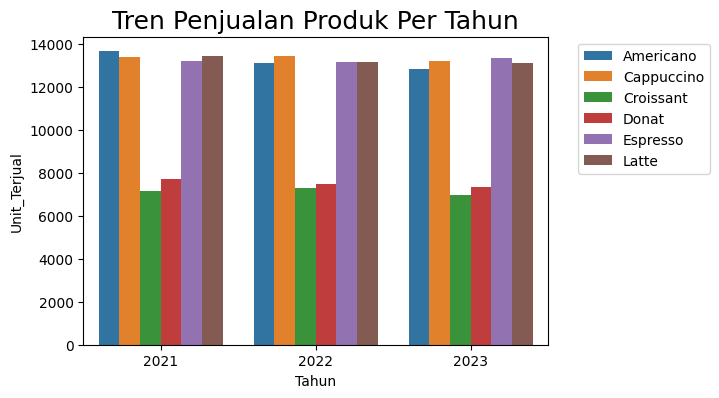

In [29]:
plt.figure(figsize=(6,4))
plt.title('Tren Penjualan Produk Per Tahun', fontsize = 18)
tren_produk = sns.barplot(df_laris,x='Tahun',y='Unit_Terjual', hue='Produk')
plt.legend(bbox_to_anchor=(1.05,0.5,0.5,0.5), loc='upper left')
plt.savefig('tren_produk.png', dpi=300, bbox_inches='tight')
tren_produk


/tmp/ipykernel_260/3016606478.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  produk_terlaris['Label'] = produk_terlaris['Produk'].astype(str)+"\n"+produk_terlaris['Tahun'].astype(str)


Text(0.5, -1.4777777777777832, 'Produk')

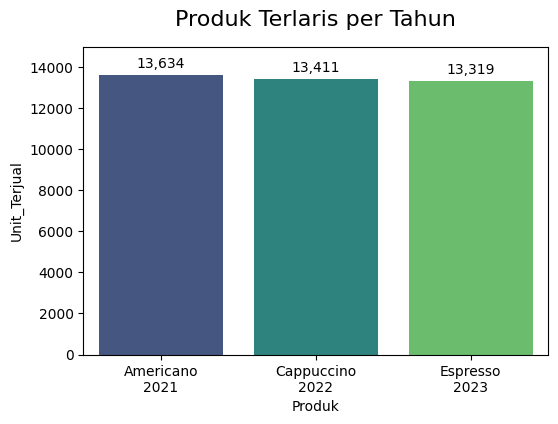

In [16]:
plt.figure(figsize=(6,4))
produk_terlaris['Label'] = produk_terlaris['Produk'].astype(str)+"\n"+produk_terlaris['Tahun'].astype(str)
plt.title('Produk Terlaris per Tahun', fontsize = 16, pad=15)
plt.ylim(0, produk_terlaris['Unit_Terjual'].max() * 1.1)

tren_tahun = sns.barplot(produk_terlaris, x='Label', y='Unit_Terjual',hue='Produk', palette='viridis', legend=False )
for container in tren_tahun.containers:
  labels = [f'{int(v):,}' for v in container.datavalues]
  tren_tahun.bar_label(container,labels=labels, padding=3)
plt.savefig('tren_tahun.png', dpi=300, bbox_inches='tight')
plt.xlabel('Produk')




---


## TUGAS 5: Rangkuman & Insight

- Tulis ringkasan hasil:
- Sampaikan minimal 2 rekomendasi untuk bisnis.

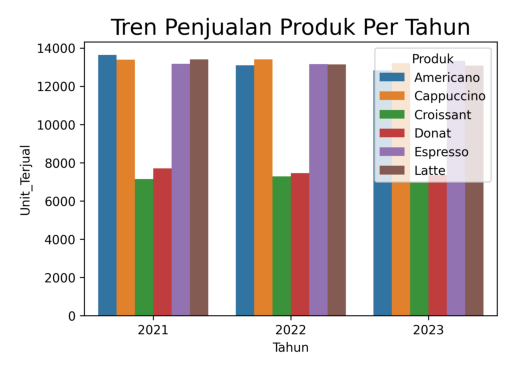

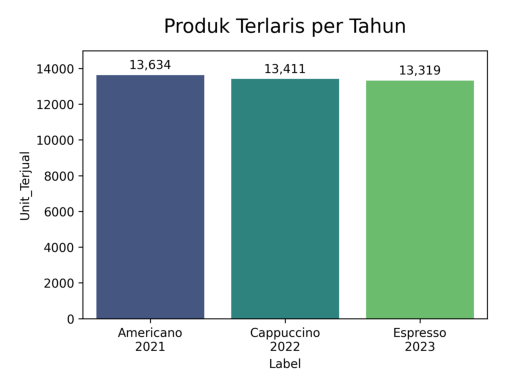

In [17]:
import matplotlib.image as mpimg

img = mpimg.imread('tren_produk.png')
img1 = mpimg.imread('tren_tahun.png')
plt.imshow(img)
plt.axis('off')
plt.show()
plt.imshow(img1)
plt.axis('off')
plt.show()


In [18]:
df_ringkasan_tahun = df4.groupby(['Tahun'])['Pendapatan'].sum().reset_index()
df_ringkasan_tahun['Pendapatan'] = df_ringkasan_tahun['Pendapatan'].astype(float)
pd.options.display.float_format = '{:,.2f}'.format
df_ringkasan_tahun['Pertumbuhan%'] = ((df_ringkasan_tahun['Pendapatan']-df_ringkasan_tahun['Pendapatan'].shift(1))*100/df_ringkasan_tahun['Pendapatan'].shift(1)).fillna(0)
df_ringkasan_tahun
# df_ringkasan_tahun.info()

,Tahun,Pendapatan,Pertumbuhan%
0,2021,"1,530,649,000.00",0.00
1,2022,"1,540,562,100.00",0.65
2,2023,"1,554,276,880.00",0.89


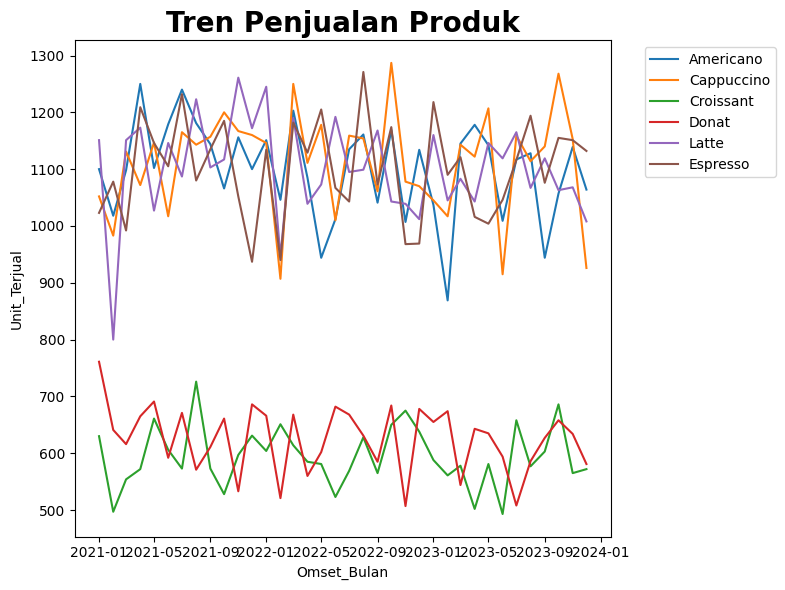

In [19]:
# mencari pertumbuhan per produk dan per bulan
df5 = df4.copy()
df5['Bulan_Angka'] = df5['Bulan'].map(bulan_ref)
df_tren_unit = df5.groupby(['Produk','Bulan_Angka','Tahun'])['Unit_Terjual'].sum().reset_index()
df_tren_unit = df_tren_unit.sort_values(['Produk','Bulan_Angka'])
df_tren_unit = df_tren_unit.sort_values(['Tahun'])
df_tren_unit['Omset_Bulan'] = pd.to_datetime((df_tren_unit[['Bulan_Angka', 'Tahun']]).assign(day=1).rename(columns={'Bulan_Angka':'month','Tahun':'year'}))
df_tren_unit
plt.figure(figsize=(8,6))
plt.title('Tren Penjualan Produk',fontsize=20, fontweight='bold')
sns.lineplot(df_tren_unit,x='Omset_Bulan',y='Unit_Terjual',hue='Produk',markers='o')
plt.legend(bbox_to_anchor=(1.05,0.5,0.5,0.5), loc='upper left')
plt.tight_layout()
plt.savefig('tren_penjualan_produk.png', dpi=300, bbox_inches='tight')



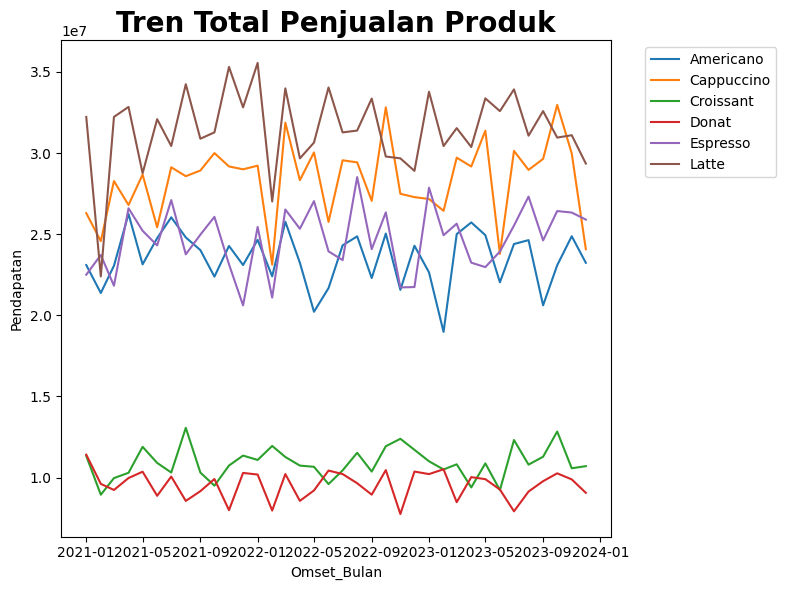

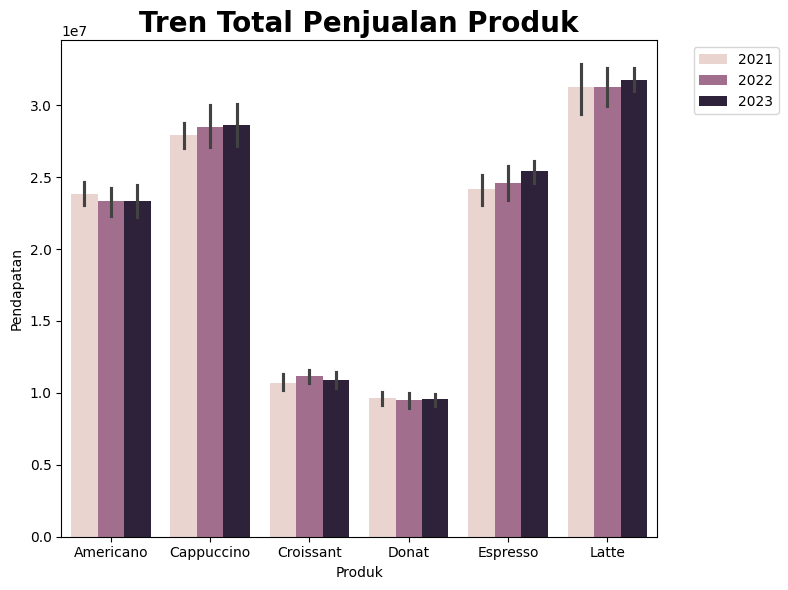

In [20]:
df_total_penjualan = df5.groupby(['Tahun','Bulan_Angka','Produk'])['Pendapatan'].sum().reset_index()
df_total_penjualan['Omset_Bulan'] = pd.to_datetime((df_total_penjualan[['Bulan_Angka', 'Tahun']]).assign(day=1).rename(columns={'Bulan_Angka':'month','Tahun':'year'}))
df_total_penjualan
plt.figure(figsize=(8,6))
plt.title('Tren Total Penjualan Produk',fontsize=20, fontweight='bold')
sns.lineplot(df_total_penjualan,x='Omset_Bulan',y='Pendapatan',hue='Produk',markers='o')
plt.legend(bbox_to_anchor=(1.05,0.5,0.5,0.5), loc='upper left')
plt.tight_layout()
plt.savefig('tren_total_penjualan_produk_line.png', dpi=300, bbox_inches='tight')
plt.figure(figsize=(8,6))
plt.title('Tren Total Penjualan Produk',fontsize=20, fontweight='bold')

sns.barplot(df_total_penjualan,x='Produk',y='Pendapatan',hue='Tahun')
plt.legend(bbox_to_anchor=(1.05,0.5,0.5,0.5), loc='upper left')
plt.tight_layout()
plt.savefig('tren_total_penjualan_produk_bar.png', dpi=300, bbox_inches='tight')
# df5.info()

In [71]:
kategori_produk = {
    'Croissant' : 'Makanan',
    'Donat' : 'Makanan',
    'Espresso' : 'Minuman',
    'Latte' : 'Minuman',
    'Cappuccino' : 'Minuman',
    'Americano' : 'Minuman'
}
df6 = df5.copy()
df6['kategori'] = df6['Produk'].map(kategori_produk)
# df_foodtobev_rev = df6.groupby(['Tahun','kategori']).agg({'Pendapatan' : 'sum'})
df_makanan = df6[df6['kategori'] == 'Makanan']
df_minuman = df6[df6['kategori'] == 'Minuman']
rasio_rev_food = df_makanan['Pendapatan'].sum() *100/ df6['Pendapatan'].sum()
rasio_rev_bev = df_minuman['Pendapatan'].sum() *100/ df6['Pendapatan'].sum()
rasio_unit_food = df_makanan['Unit_Terjual'].sum() *100/ df6['Unit_Terjual'].sum()
rasio_unit_bev = df_minuman['Unit_Terjual'].sum() *100/ df6['Unit_Terjual'].sum()
print(rasio_rev_food)
print(rasio_rev_bev)
print(rasio_unit_food)
print(rasio_unit_bev)


15.927724019293636
84.07227598070637
21.646377555046957
78.35362244495305


<font size= '24'><center>Analisa KopiNangKau</center> </font>
<p>&emsp;Berdasarkan grafik penjualan dari tahun ke tahun untuk KopiNangKau, kita mendapati 2 kesimpulan secara garis besar yaitu penurunan volume penjualan dan kenaikan total pendapatan. Volume penjualan tahunan menurun dan dapat diperjelas dengan grafik penjualan tertinggi tiap tahun yang kian menurun dengan rincian sebagai berikut :<br>
Americano (2021) total 13.634 unit --> Cappuccino (2022) total 13.411 unit --> Espresso (2023) total 13.319 unit. <br>
Ini mengindikasikan penurun sebesar 315 unit (2.31%) dalam 3 tahun tersebut dalam best-seller product. <br>
Sedangkan untuk kenaikan total pendapatan 0.65% di tahun ke2 dan 0.89% di tahun ke3. Ini jauh di bawah angka pertumbuhan yang rasional dimana inflasi mengalahkan total pertumbuhan dalam sebuah bisnis.
<p>
Solusi :<br>

1.   <b>Meningkatkan overall penjualan</b><br>
Memulai campaign dengan channel lain seperti mendaftarkan bisnis di dalam servis makanan online dan mempekerjakan influencer setempat untuk meningkatkan awareness dan penjualan. Cara lain adalah dengan menggunakan strategi customer retention yaitu dengan membagikan voucher pembelian contoh seperti pembelian ke sepuluh mendapatkan minuman atau makanan secara gratis.<p>
2.   <b>Meningkatkan campaign penjualan makanan</b><br>
Perbandingan rasio makanan dan minuman secara pendapatan keseluruhan masing-masing adalah 15.93% dan 84.07% dengan volume 21.65% dan 78.35%. Ini menunjukkan masih ada ruang gerak promosi atau marketing terhadap produk makanan yang dimana kita masih bisa menyesuaikan sebagian porsi campaign dari minuman ke makanan atau dengan cross bundling dari minuman ke mananan dengan diskon.<p>



## 🌟 Tugas Opsional / Challenge (Pilihan):



1. **Identifikasi Bulan Tertinggi dan Terendah**
   
   - Temukan bulan dan tahun dengan total penjualan unit tertinggi dan terendah (dalam seluruh periode).
   - Visualisasikan trennya (misal line chart penjualan bulanan).

2. **Analisis Pertumbuhan Penjualan**
   
   - Bandingkan total penjualan (unit terjual maupun pendapatan) antar tahun 2021, 2022, dan 2023.
   - Produk apa yang pertumbuhannya paling tinggi selama 3 tahun?
   - Tampilkan hasilnya dalam bentuk tabel ringkasan pertumbuhan dan/atau visualisasi sederhana.

3. **Simulasi Promo Diskon**
   
   - Simulasikan jika ada diskon 10% untuk produk minuman di bulan-bulan tertentu (misal: Juli & Agustus), dan asumsikan penjualan produk-produk ini naik 15% di bulan promo.
   - Hitung dan bandingkan pendapatan asli vs pendapatan setelah promo.
   - Jelaskan insight-nya, apakah strategi promo ini efektif? (Boleh angka “kasar”, tidak harus persis.)

4. **Deteksi Outlier**
   
   - Temukan hari-hari/tanggal tertentu dimana penjualan produk “melonjak tidak wajar” (misal, tiga kali lipat dari median hariannya).
   - Buat list tanggal tersebut dan sebutkan produk apa saja yang menjadi “outlier”.
   - Akan lebih baik jika langsung ditampilkan dalam bentuk boxplot

5. **Cek Konsistensi Harga**
   
   - Adakah harga produk yang tidak sesuai aturan/rumus kenaikan 2% per tahun? (Cek kolom Harga_Per_Unit)
   - Jika ada data yang tidak konsisten, tampilkan semua kasusnya dan buat analisa ringkas.

---

**Instruksi untuk peserta (opsional):**
Pilih satu atau lebih tugas opsional di atas, lakukan analisis menggunakan pandas, groupby, serta visualisasi yang dikuasai. Laporan insight dan hasil analisis ditulis ringkas namun jelas.

---

Still hungry of challenge ?
[Try this dataset](https://drive.google.com/file/d/1XQDy8Li_EKcC1QOez1dtjKLguY_MyVOO/view?usp=drive_link)